In [ ]:
import cv2
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import numpy as np

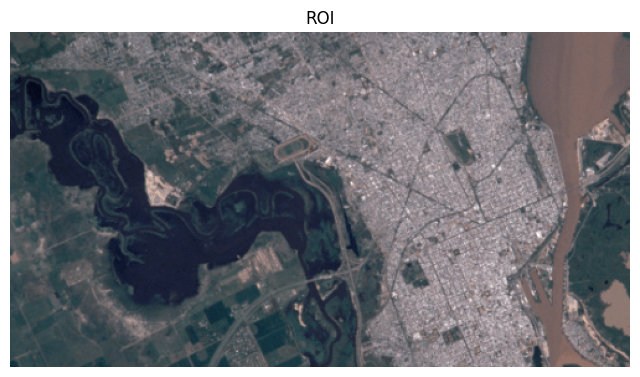

In [ ]:
image = cv2.imread('imagen_satelital.png')
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

#r = [0,0,738,491]
r = [0,70,500,270] # x, y, width, heigh
roi = image_rgb[int(r[1]):int(r[1]+r[3]), int(r[0]):int(r[0]+r[2])] # Seleccionar zona de Interes en base a r

plt.figure(figsize=(8,6))
plt.imshow(roi)
plt.title("ROI")
plt.axis("off")
plt.show()

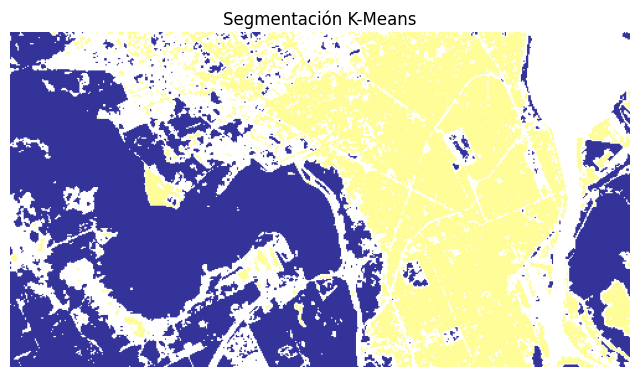

In [ ]:
pixels = roi.reshape((-1, 3))
kmeans = KMeans(n_clusters=3, random_state=42).fit(pixels)
segmented = kmeans.labels_.reshape(roi.shape[:2])

plt.figure(figsize=(8,6))
plt.imshow(segmented, cmap='terrain')
plt.title("Segmentación K-Means")
plt.axis("off")
plt.show()

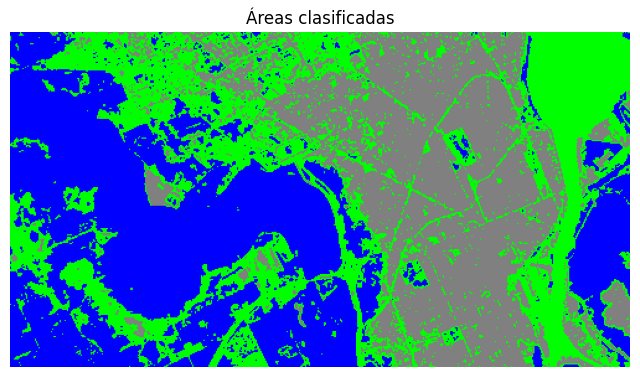

In [ ]:
colored = np.zeros((segmented.shape[0], segmented.shape[1], 3),
                   dtype=np.uint8)

# colored[segmented == 0] = [0, 255, 0]       # verde
# colored[segmented == 1] = [0, 0, 255]       # azul
# colored[segmented == 2] = [128, 128, 128]   # gris

colored[segmented == 0] = [0, 0, 255]
colored[segmented == 1] = [128, 128, 128]
colored[segmented == 2] = [0, 255, 0]

plt.figure(figsize=(8,6))
plt.imshow(colored)
plt.title("Áreas clasificadas")
plt.axis("off")
plt.show()

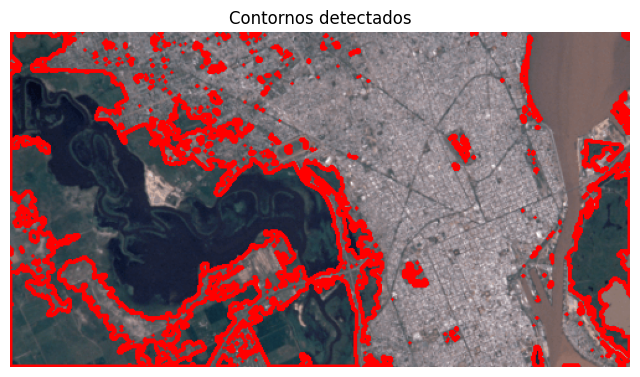

In [ ]:
mask = np.uint8(segmented == 0)

contours, _ = cv2.findContours(
    mask,
    cv2.RETR_EXTERNAL,
    cv2.CHAIN_APPROX_SIMPLE
)

result = roi.copy()

cv2.drawContours(
    result,
    contours,
    -1,
    (255, 0, 0),
    2
)

plt.figure(figsize=(8,6))
plt.imshow(result)
plt.title("Contornos detectados")
plt.axis("off")
plt.show()

In [ ]:
for cnt in contours:

    area = cv2.contourArea(cnt)

    if area > 100:

        x, y, w, h = cv2.boundingRect(cnt)

        cv2.putText(
            result,
            "Bosque",
            (x, y-5),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.5,
            (255,0,0),
            1
        )

forest_mask = np.uint8(segmented == 0) * 255
water_mask = np.uint8(segmented == 1) * 255
urban_mask = np.uint8(segmented == 2) * 255

cv2.imwrite("agua.png", forest_mask)
cv2.imwrite("urbano.png", water_mask)
cv2.imwrite("zona_verde.png", urban_mask)

True

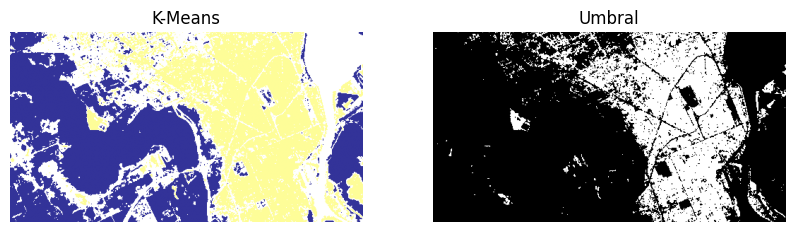

In [ ]:
green = roi[:,:,1]

_, threshold = cv2.threshold(
    green,
    120,
    255,
    cv2.THRESH_BINARY
)

plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.imshow(segmented, cmap="terrain")
plt.axis("off")
plt.title("K-Means")

plt.subplot(1,2,2)
plt.imshow(threshold, cmap="gray")
plt.axis("off")
plt.title("Umbral")

plt.show()